# AdaBoost Immunogenicity Predictor

In [50]:
import pandas as pd
import numpy as np
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

## Load and Preprocess data

In [51]:
df = pd.read_csv("../data/features/processed_data_with_position_specific_features.csv")

#Drop non feature columns
DROP_COLS = ["peptide", "hla_sequence", "index"]
TARGET_COL = "Label"

df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

#Identify categorical columns
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
cat_cols = [c for c in cat_cols if c != TARGET_COL]
print(f"Encoding categorical columns: {cat_cols}")

df = pd.get_dummies(df, columns=cat_cols) #Hot encode to get numeric input for Adaboost

# Split x and y values
y = df[TARGET_COL].values
X = df.drop(columns=[TARGET_COL])

print(df.columns.tolist()) #check what columns exist

print(f"Features: {X.shape}, Classes: {dict(zip(*np.unique(y, return_counts=True)))}")

Encoding categorical columns: ['HLA']
['Label', 'PeptidePos_p1_f1', 'PeptidePos_p1_f2', 'PeptidePos_p1_f3', 'PeptidePos_p1_f4', 'PeptidePos_p1_f5', 'PeptidePos_p1_f6', 'PeptidePos_p1_f7', 'PeptidePos_p1_f8', 'PeptidePos_p1_f9', 'PeptidePos_p1_f10', 'PeptidePos_p1_f11', 'PeptidePos_p1_f12', 'PeptidePos_p1_f13', 'PeptidePos_p1_f14', 'PeptidePos_p1_f15', 'PeptidePos_p1_f16', 'PeptidePos_p1_f17', 'PeptidePos_p1_f18', 'PeptidePos_p2_f1', 'PeptidePos_p2_f2', 'PeptidePos_p2_f3', 'PeptidePos_p2_f4', 'PeptidePos_p2_f5', 'PeptidePos_p2_f6', 'PeptidePos_p2_f7', 'PeptidePos_p2_f8', 'PeptidePos_p2_f9', 'PeptidePos_p2_f10', 'PeptidePos_p2_f11', 'PeptidePos_p2_f12', 'PeptidePos_p2_f13', 'PeptidePos_p2_f14', 'PeptidePos_p2_f15', 'PeptidePos_p2_f16', 'PeptidePos_p2_f17', 'PeptidePos_p2_f18', 'PeptidePos_p3_f1', 'PeptidePos_p3_f2', 'PeptidePos_p3_f3', 'PeptidePos_p3_f4', 'PeptidePos_p3_f5', 'PeptidePos_p3_f6', 'PeptidePos_p3_f7', 'PeptidePos_p3_f8', 'PeptidePos_p3_f9', 'PeptidePos_p3_f10', 'PeptidePos_p

## Load predefined splits

In [52]:
train_idx = np.load("../data/splits/train_idx.npy")
val_idx = np.load("../data/splits/val_idx.npy")
test_idx = np.load("../data/splits/test_idx.npy")

X_train, y_train = X.iloc[train_idx], y[train_idx]
X_val, y_val     = X.iloc[val_idx], y[val_idx]
X_test, y_test   = X.iloc[test_idx], y[test_idx]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (5707, 394), Val: (1446, 394), Test: (1815, 394)


## Train AdaBoost Classifier

In [53]:
model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=400,
    learning_rate=0.5,
    random_state=42
)
model.fit(X_train, y_train)
print("Model trained!!")

Model trained!!


## Sanity check of train and test datasets

In [54]:
print("Train size:", X_train.shape, y_train.shape)
print("Test size:", X_test.shape, y_test.shape)
print("Label distribution in train:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Label distribution in test:", dict(zip(*np.unique(y_test, return_counts=True))))
print("Any overlap between train and test idx:", len(set(train_idx) & set(test_idx)))

Train size: (5707, 394) (5707,)
Test size: (1815, 394) (1815,)
Label distribution in train: {np.int64(0): np.int64(3143), np.int64(1): np.int64(2564)}
Label distribution in test: {np.int64(0): np.int64(991), np.int64(1): np.int64(824)}
Any overlap between train and test idx: 0


## Evaluate Model

In [55]:
# Validation
y_val_pred = model.predict(X_val)
y_val_prob = model.predict_proba(X_val)[:, 1]
print("-- Validation --")
print(f"Accuracy : {accuracy_score(y_val, y_val_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_val, y_val_prob):.4f}")

# Test
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
print("\n-- Test --")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
print(classification_report(y_test, y_pred))

-- Validation --
Accuracy : 0.7455
ROC-AUC  : 0.8302

-- Test --
Accuracy : 0.7758
ROC-AUC  : 0.8521
              precision    recall  f1-score   support

           0       0.86      0.70      0.77       991
           1       0.71      0.86      0.78       824

    accuracy                           0.78      1815
   macro avg       0.78      0.78      0.78      1815
weighted avg       0.79      0.78      0.78      1815



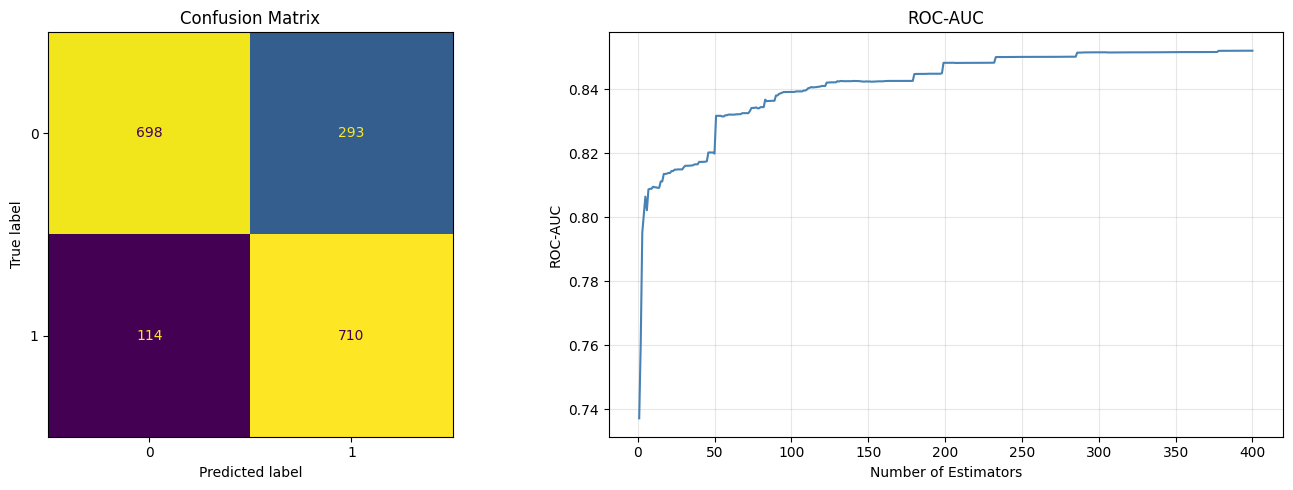

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")

staged_auc = [roc_auc_score(y_test, p[:, 1]) for p in model.staged_predict_proba(X_test)]
axes[1].plot(range(1, len(staged_auc) + 1), staged_auc, color="steelblue")
axes[1].set_xlabel("Number of Estimators")
axes[1].set_ylabel("ROC-AUC")
axes[1].set_title("ROC-AUC")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

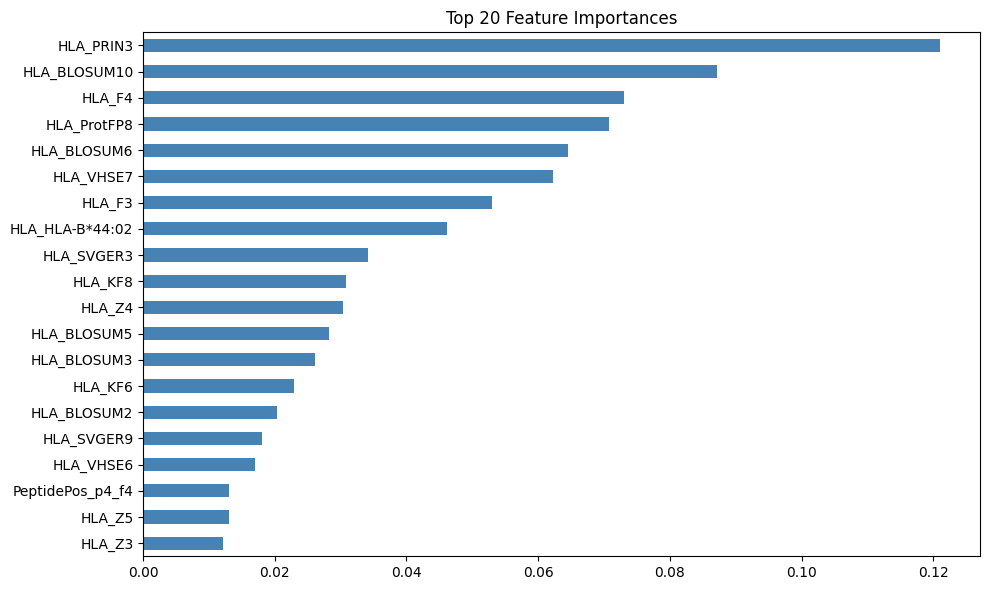

In [57]:
from utils import run_shap_analysis
#run_shap_analysis(model, X_test)
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(20).plot(kind="barh", color="steelblue", figsize=(10, 6))
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()